In [1]:
!git clone https://github.com/niaz1971/BONE_FRACTURE_CLASSIFICATION.git

Cloning into 'BONE_FRACTURE_CLASSIFICATION'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [2]:
cd BONE_FRACTURE_CLASSIFICATION

/content/BONE_FRACTURE_CLASSIFICATION


In [3]:
!pip install lime kaggle

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=c59ac89469bbe9f4b1605d9de385dd696e7326352bafea92d331d8a3263c8931
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [4]:
# Step 2: Set up Kaggle API for dataset download
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
# Step 3: Download and unzip malaria cell images dataset
!kaggle datasets download -d orvile/bone-fracture-dataset

Dataset URL: https://www.kaggle.com/datasets/orvile/bone-fracture-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
 81% 259M/319M [00:00<00:00, 601MB/s]
100% 319M/319M [00:00<00:00, 606MB/s]


In [6]:
!unzip -q bone-fracture-dataset.zip

In [7]:
cd 'Bone fracture dataset'

/content/BONE_FRACTURE_CLASSIFICATION/Bone fracture dataset


In [8]:
!ls

'Bone fracture dataset'


In [9]:
cd 'Bone fracture dataset'

/content/BONE_FRACTURE_CLASSIFICATION/Bone fracture dataset/Bone fracture dataset


In [10]:
!ls

Dataset


In [11]:
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('Dataset'):
    for filename in filenames:
        pass

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [13]:
data_dir = 'Dataset'
img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 1702 images belonging to 2 classes.
Found 425 images belonging to 2 classes.


In [14]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the base model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 59s 769ms/step - accuracy: 0.9274 - loss: 0.2669 - val_accuracy: 0.9835 - val_loss: 0.0580
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 251ms/step - accuracy: 0.9958 - loss: 0.0329 - val_accuracy: 0.9906 - val_loss: 0.0452
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 220ms/step - accuracy: 0.9999 - loss: 0.0094 - val_accuracy: 0.9906 - val_loss: 0.0249
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 222ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 0.9906 - val_loss: 0.0228
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 251ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.9906 - val_loss: 0.0198
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 229ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9906 - val_loss: 0.0197
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 226ms/step - accuracy: 1.0000 - loss: 9.3279e-04 - val_accuracy: 0.9906 - val_loss: 0.0206
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 225ms/step - accuracy: 1.0000 - loss: 8.3996e-04 - 

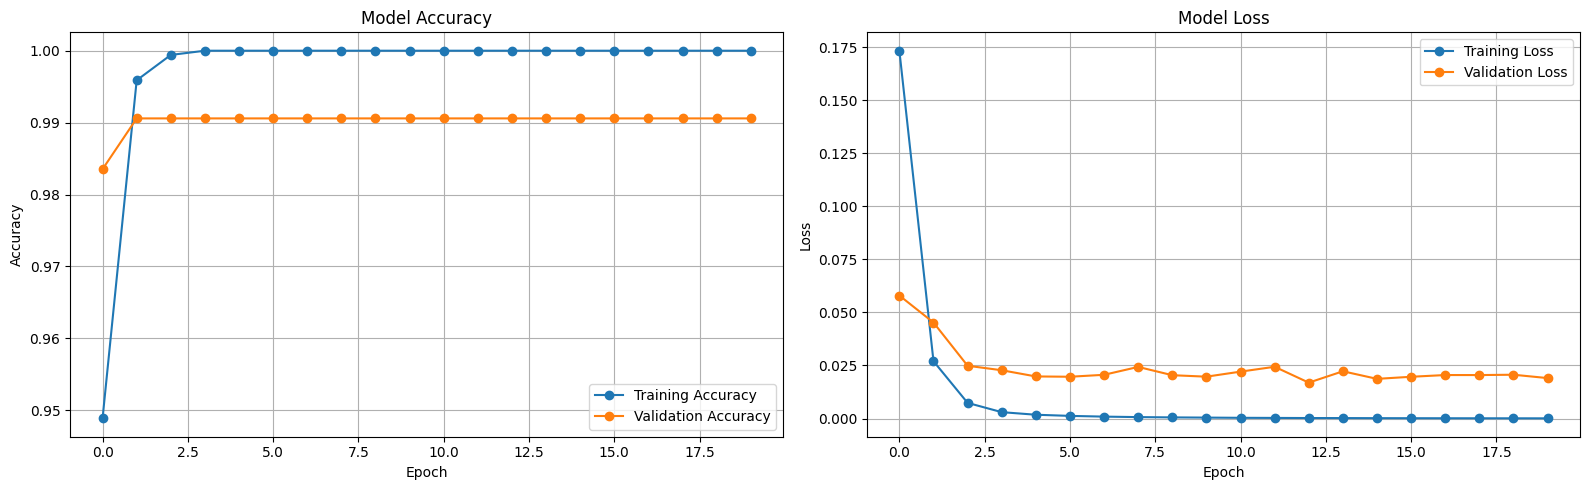

In [15]:
import matplotlib.pyplot as plt

# Create subplots first
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', marker='o')
ax2.plot(history.history['val_loss'], label='Validation Loss', marker='o')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 563ms/step


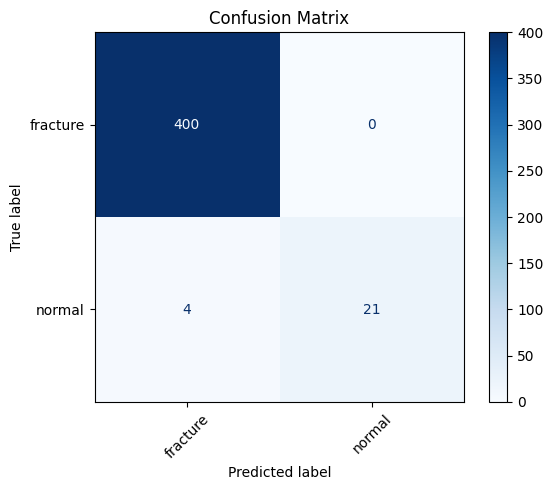

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(val_data, verbose=1)
y_pred_labels = np.argmax(y_pred, axis=1)

y_true = val_data.classes

class_names = list(val_data.class_indices.keys())

cm = confusion_matrix(y_true, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()


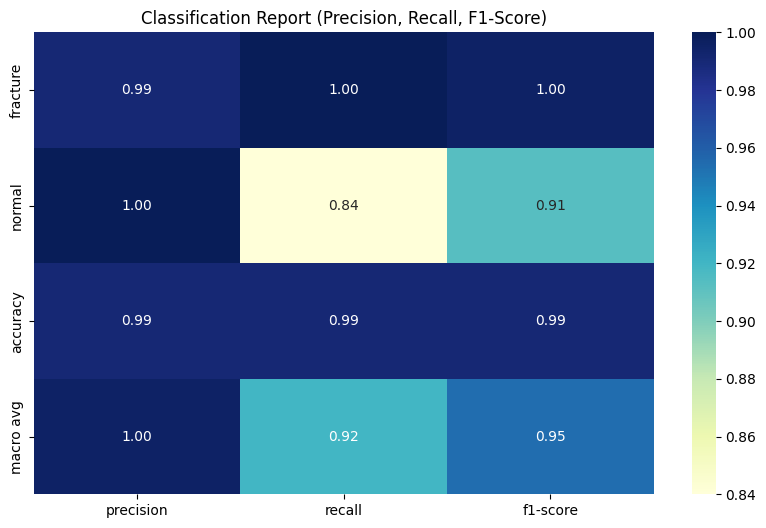

In [17]:
report = classification_report(y_true, y_pred_labels, target_names=val_data.class_indices.keys(), output_dict=True)

df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(10, 6))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report (Precision, Recall, F1-Score)")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


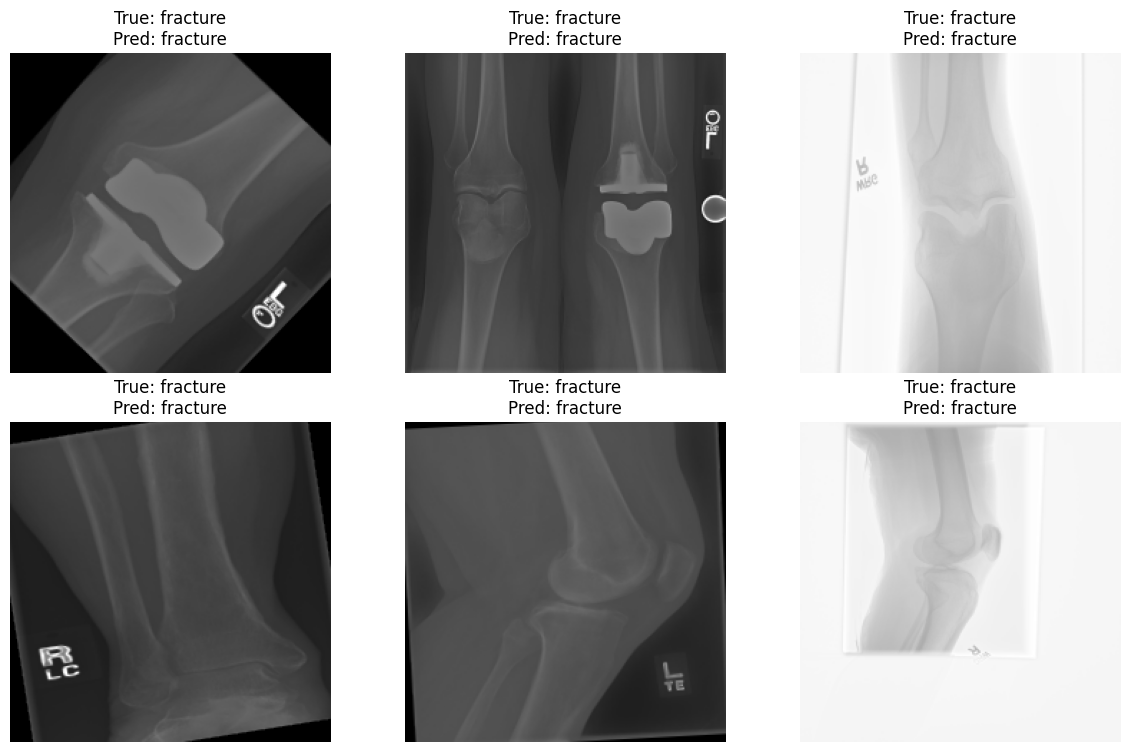

In [18]:
class_names = list(val_data.class_indices.keys())
val_data.reset()

plt.figure(figsize=(12, 8))
for i in range(6):
    image, label = val_data[i][0][0], val_data[i][1][0]
    true_label = class_names[np.argmax(label)]
    prediction = model.predict(tf.expand_dims(image, axis=0))
    pred_label = class_names[np.argmax(prediction)]

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(f"True: {true_label}\nPred: {pred_label}",
              color="black" if true_label == pred_label else "red")
    plt.axis("off")
plt.tight_layout()
#plt.suptitle("Sample Prediction Visualization", fontsize=12)
plt.subplots_adjust(top=0.88)
plt.show()


Finding misclassified samples...
Found 50 misclassified samples


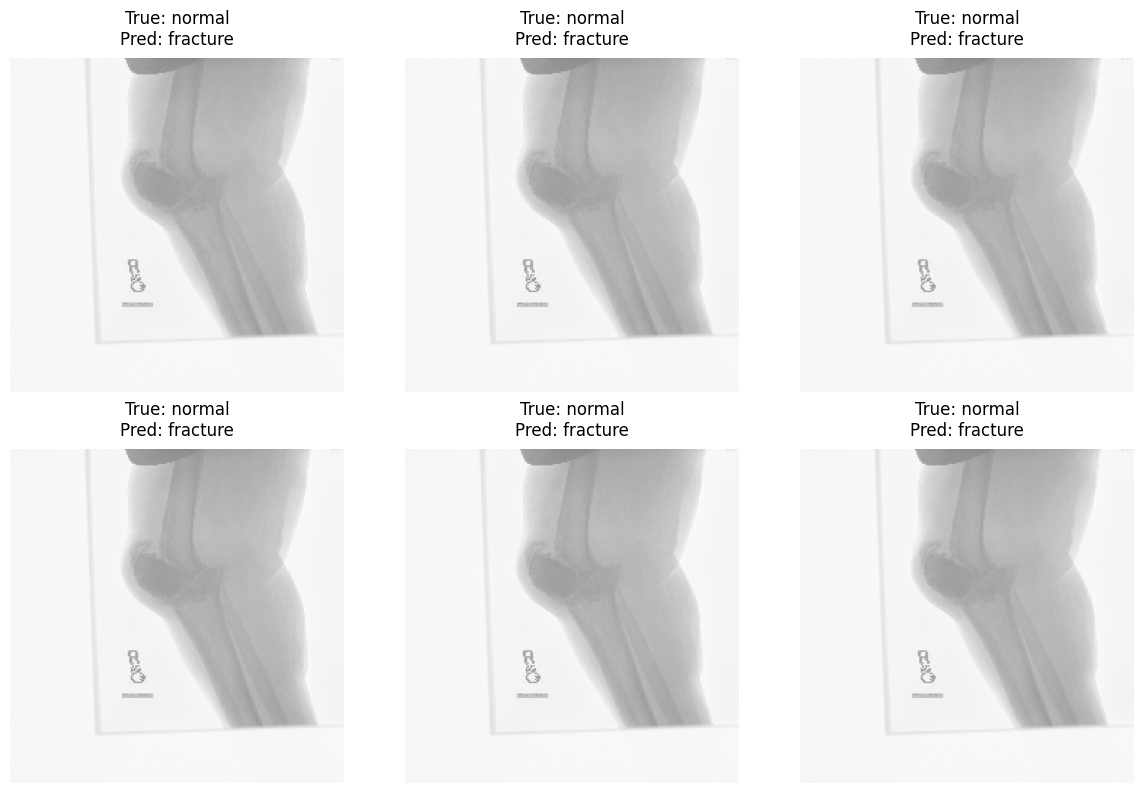

In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Reset validation data generator
class_names = list(val_data.class_indices.keys())
val_data.reset()

# Collect ALL misclassified samples first
misclassified_images = []
misclassified_true = []
misclassified_pred = []

print("Finding misclassified samples...")
for batch_images, batch_labels in val_data:
    # Predict on batch
    predictions = model.predict(batch_images, verbose=0)
    pred_classes = np.argmax(predictions, axis=1)
    true_classes = np.argmax(batch_labels, axis=1)

    # Find misclassifications in this batch
    mis_idx = np.where(pred_classes != true_classes)[0]

    for idx in mis_idx:
        misclassified_images.append(batch_images[idx])
        misclassified_true.append(class_names[true_classes[idx]])
        misclassified_pred.append(class_names[pred_classes[idx]])

    # Break if we have enough (optional)
    if len(misclassified_images) >= 50:
        break

print(f"Found {len(misclassified_images)} misclassified samples")

# Select 6 random misclassified samples
if len(misclassified_images) == 0:
    print("No misclassifications found!")
else:
    num_show = min(6, len(misclassified_images))
    random_indices = np.random.choice(len(misclassified_images), num_show, replace=False)

    plt.figure(figsize=(12, 8))
    for i, idx in enumerate(random_indices):
        image = misclassified_images[idx]
        true_label = misclassified_true[idx]
        pred_label = misclassified_pred[idx]

        plt.subplot(2, 3, i + 1)
        plt.imshow(image)
        plt.title(f'True: {true_label}\nPred: {pred_label}',
                 color='black', fontsize=12, pad=10)
        plt.axis('off')

    #plt.suptitle(f'Misclassified Images ({num_show} samples)',
                #fontsize=16, y=0.95)
    plt.tight_layout()
    plt.show()